# Factor Analysis on Big Five Personality Dataset

This notebook performs comprehensive factor analysis on the Big Five personality test dataset, determines the optimal number of factors, and provides semantic interpretations.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Load and Explore the Data

In [2]:
file_path = r'data/demo_data/big_five/data-sample.csv'
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nFirst Few Rows:")
print(df.head())

# Identify personality test columns (EXT, EST, AGR, CSN, OPN)
personality_columns = [col for col in df.columns if any(prefix in col for prefix in ['EXT', 'EST', 'AGR', 'CSN', 'OPN']) and '_E' not in col and col[3:].isdigit()]

print(f"\n\nPersonality Test Columns ({len(personality_columns)} total):")
print(personality_columns[:10], "...", personality_columns[-5:] if len(personality_columns) > 15 else "")

print(f"\nData Types:")
print(df[personality_columns].dtypes.value_counts())

print(f"\nMissing Values in Personality Questions:")
print(df[personality_columns].isnull().sum().sum())

print(f"\nBasic Statistics:")
print(df[personality_columns].describe())

Dataset Shape: (100, 110)

First Few Rows:
   EXT1  EXT2  EXT3  EXT4  EXT5  EXT6  EXT7  EXT8  EXT9  EXT10  ...  \
0     1     5     2     4     2     5     1     4     4      2  ...   
1     4     4     2     3     2     2     2     3     4      4  ...   
2     1     2     4     3     4     3     0     4     4      2  ...   
3     3     3     3     3     3     3     1     0     1      4  ...   
4     1     5     2     5     2     4     1     5     1      4  ...   

          dateload  screenw  screenh  introelapse  testelapse  endelapse  IPC  \
0   7/6/2018 13:34   1280.0    720.0          8.0         246         16    1   
1   3/11/2017 0:05    375.0    667.0          2.0         192          6    1   
2    4/4/2018 2:07   1536.0    864.0          4.0         315          9    1   
3  10/3/2016 16:10   1920.0   1080.0          7.0         258         12    1   
4   3/3/2018 16:04    360.0    740.0          5.0         173         87    2   

   country  lat_appx_lots_of_err  long_appx

## 3. Data Preprocessing and Standardization

In [3]:
# Drop rows with missing values in personality columns
df_clean = df[personality_columns].dropna()

print(f"Original dataset shape: {df[personality_columns].shape}")
print(f"Cleaned dataset shape (after removing NaN): {df_clean.shape}")

# Prepare features for Factor Analysis
X = df_clean.copy()

# Standardize the data (crucial for factor analysis)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeatures used for Factor Analysis ({len(X.columns)} total):")
print(f"Columns: {X.columns.tolist()[:20]} ... and {len(X.columns)-20} more")

print(f"\nScaled data shape: {X_scaled.shape}")
print(f"Mean of scaled features (should be ~0): {X_scaled.mean(axis=0)[:5]}")
print(f"Std of scaled features (should be ~1): {X_scaled.std(axis=0)[:5]}")

Original dataset shape: (100, 50)
Cleaned dataset shape (after removing NaN): (100, 50)

Features used for Factor Analysis (50 total):
Columns: ['EXT1', 'EXT2', 'EXT3', 'EXT4', 'EXT5', 'EXT6', 'EXT7', 'EXT8', 'EXT9', 'EXT10', 'EST1', 'EST2', 'EST3', 'EST4', 'EST5', 'EST6', 'EST7', 'EST8', 'EST9', 'EST10'] ... and 30 more

Scaled data shape: (100, 50)
Mean of scaled features (should be ~0): [ 1.39888101e-16 -1.48769885e-16  1.27675648e-16 -1.95399252e-16
 -1.27675648e-16]
Std of scaled features (should be ~1): [1. 1. 1. 1. 1.]


## 4. Determine the Optimal Number of Factors

We'll test multiple factor counts using scree plot analysis and cumulative explained variance.

In [4]:
# Test different numbers of factors
n_features = X_scaled.shape[1]
max_factors = min(n_features - 1, 12)  # Test up to 12 factors
n_factors_range = range(1, max_factors + 1)

# Store metrics for each factor count
variance_explained_list = []
log_likelihood_list = []
reconstruction_error_list = []

for n_factors in n_factors_range:
    fa = FactorAnalysis(n_components=n_factors, random_state=42, max_iter=500)
    fa.fit(X_scaled)
    
    # Compute reconstruction error
    X_reconstructed = fa.transform(X_scaled) @ fa.components_ + fa.mean_
    mse = np.mean((X_scaled - X_reconstructed) ** 2)
    var_explained = 1 - (mse / np.var(X_scaled))
    
    variance_explained_list.append(max(0, var_explained) * 100)
    log_likelihood_list.append(fa.score(X_scaled))
    reconstruction_error_list.append(mse)

# Create results DataFrame
results_df = pd.DataFrame({
    'n_factors': list(n_factors_range),
    'variance_explained': variance_explained_list,
    'log_likelihood': log_likelihood_list,
    'reconstruction_error': reconstruction_error_list
})

print("Factor Analysis Results:")
print(results_df.to_string())


Factor Analysis Results:
    n_factors  variance_explained  log_likelihood  reconstruction_error
0           1           14.903125      -67.934350              0.850969
1           2           26.734606      -65.645998              0.732654
2           3           36.756441      -63.458482              0.632436
3           4           43.212177      -62.124291              0.567878
4           5           49.170714      -60.889424              0.508293
5           6           53.809231      -59.802396              0.461908
6           7           57.034092      -59.155475              0.429659
7           8           60.045824      -58.579963              0.399542
8           9           62.231158      -58.249888              0.377688
9          10           64.435625      -57.843528              0.355644
10         11           66.463350      -57.513269              0.335367
11         12           68.081496      -57.121361              0.319185


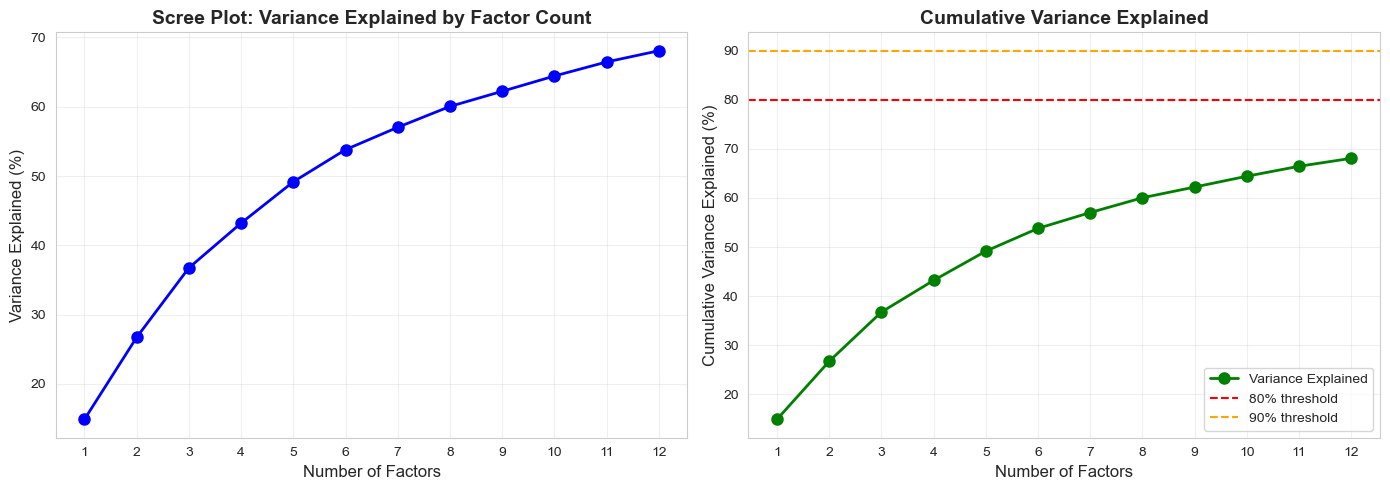


OPTIMAL NUMBER OF FACTORS ANALYSIS
Optimal number of factors (elbow method): 9
Variance explained with 9 factors: 62.23%
Log-likelihood: -58.2499
Reconstruction error (MSE): 0.377688


In [5]:
# Plot Scree Plot and Cumulative Variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].plot(results_df['n_factors'], results_df['variance_explained'], 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Factors', fontsize=12)
axes[0].set_ylabel('Variance Explained (%)', fontsize=12)
axes[0].set_title('Scree Plot: Variance Explained by Factor Count', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(n_factors_range))

# Cumulative variance with thresholds
axes[1].plot(results_df['n_factors'], results_df['variance_explained'], 'go-', linewidth=2, markersize=8, label='Variance Explained')
axes[1].axhline(y=80, color='r', linestyle='--', label='80% threshold')
axes[1].axhline(y=90, color='orange', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Factors', fontsize=12)
axes[1].set_ylabel('Cumulative Variance Explained (%)', fontsize=12)
axes[1].set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)
axes[1].set_xticks(list(n_factors_range))

plt.tight_layout()
plt.show()

# Find optimal number of factors using elbow method
# Look for diminishing returns (where adding more factors provides < 3% improvement)
differences = np.diff(results_df['variance_explained'].values)
optimal_idx = np.argmax(differences < 3) + 1
if optimal_idx == 1:
    optimal_idx = 2

optimal_factors = results_df['n_factors'].iloc[optimal_idx]

print(f"\n{'='*70}")
print(f"OPTIMAL NUMBER OF FACTORS ANALYSIS")
print(f"{'='*70}")
print(f"Optimal number of factors (elbow method): {optimal_factors}")
print(f"Variance explained with {optimal_factors} factors: {results_df['variance_explained'].iloc[optimal_idx]:.2f}%")
print(f"Log-likelihood: {results_df['log_likelihood'].iloc[optimal_idx]:.4f}")
print(f"Reconstruction error (MSE): {results_df['reconstruction_error'].iloc[optimal_idx]:.6f}")
print(f"{'='*70}")

## 5. Perform Factor Analysis with Optimal Number of Factors

In [6]:
# Fit Factor Analysis with optimal number of factors
fa_optimal = FactorAnalysis(n_components=int(optimal_factors), random_state=42, max_iter=500)
fa_optimal.fit(X_scaled)

# Transform the data
X_factors = fa_optimal.transform(X_scaled)

print(f"Factor Analysis Model Fitted")
print(f"Number of factors: {fa_optimal.n_components}")
print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Factor scores shape: {X_factors.shape}")
print(f"\nDimensionality reduction: {(1 - fa_optimal.n_components/X_scaled.shape[1])*100:.1f}%")

# Create DataFrame with factor scores
factors_df = pd.DataFrame(
    X_factors,
    columns=[f'Factor {i+1}' for i in range(fa_optimal.n_components)]
)

print("\nFactor Scores (first 10 respondents):")
print(factors_df.head(10))

Factor Analysis Model Fitted
Number of factors: 9
Original number of features: 50
Factor scores shape: (100, 9)

Dimensionality reduction: 82.0%

Factor Scores (first 10 respondents):
   Factor 1  Factor 2  Factor 3  Factor 4  Factor 5  Factor 6  Factor 7  \
0 -1.558307  1.477009  0.660042  1.278908  0.386923 -1.148344 -0.559245   
1 -0.746391  0.024064  0.940851 -0.385407 -0.343450  0.472859  0.959133   
2 -0.635689  0.500160  0.716275  0.504526 -0.057133 -0.196082 -0.942849   
3 -0.528047 -0.268159  0.987401  0.685030  1.256350  0.482463 -1.788757   
4 -0.934084  0.229468 -0.410978  0.048977  1.407791 -1.294606  0.588496   
5 -0.137739  0.047848 -1.679588 -0.963858  0.721920  0.247446 -0.452958   
6 -1.777351  1.818058 -0.941414 -0.010515 -0.906806 -0.874407 -1.743306   
7  0.120577  0.680946 -0.112862 -0.587746 -0.049930  0.037445  0.132243   
8 -0.779087  0.346134  0.627476  1.128258 -0.071984  0.023540 -0.159355   
9  0.380571  5.224548  1.887092 -0.153033  2.756191  4.391177  0.3

## 6. Extract and Interpret Factor Loadings

Factor Loadings (top 15 features shown):
       Factor 1  Factor 2  Factor 3  Factor 4  Factor 5  Factor 6  Factor 7  \
EXT1      0.329    -0.042     0.287     0.072    -0.126     0.092     0.058   
EXT2     -0.352     0.023    -0.289    -0.097     0.085    -0.120     0.034   
EXT3      0.385    -0.049     0.048     0.076    -0.146    -0.091    -0.052   
EXT4     -0.339    -0.080    -0.247    -0.004     0.024    -0.067     0.056   
EXT5      0.340    -0.169     0.152     0.071    -0.210     0.012    -0.047   
EXT6     -0.412     0.108    -0.150     0.037     0.062    -0.136     0.069   
EXT7      0.387    -0.130     0.150     0.122    -0.132    -0.034    -0.060   
EXT8     -0.231     0.011    -0.371    -0.051    -0.123    -0.084     0.002   
EXT9      0.323    -0.182     0.257     0.087    -0.167    -0.061     0.041   
EXT10    -0.354    -0.052    -0.291    -0.113     0.009    -0.072     0.039   
EST1     -0.261    -0.320     0.052     0.183     0.119     0.073     0.000   
EST2      0

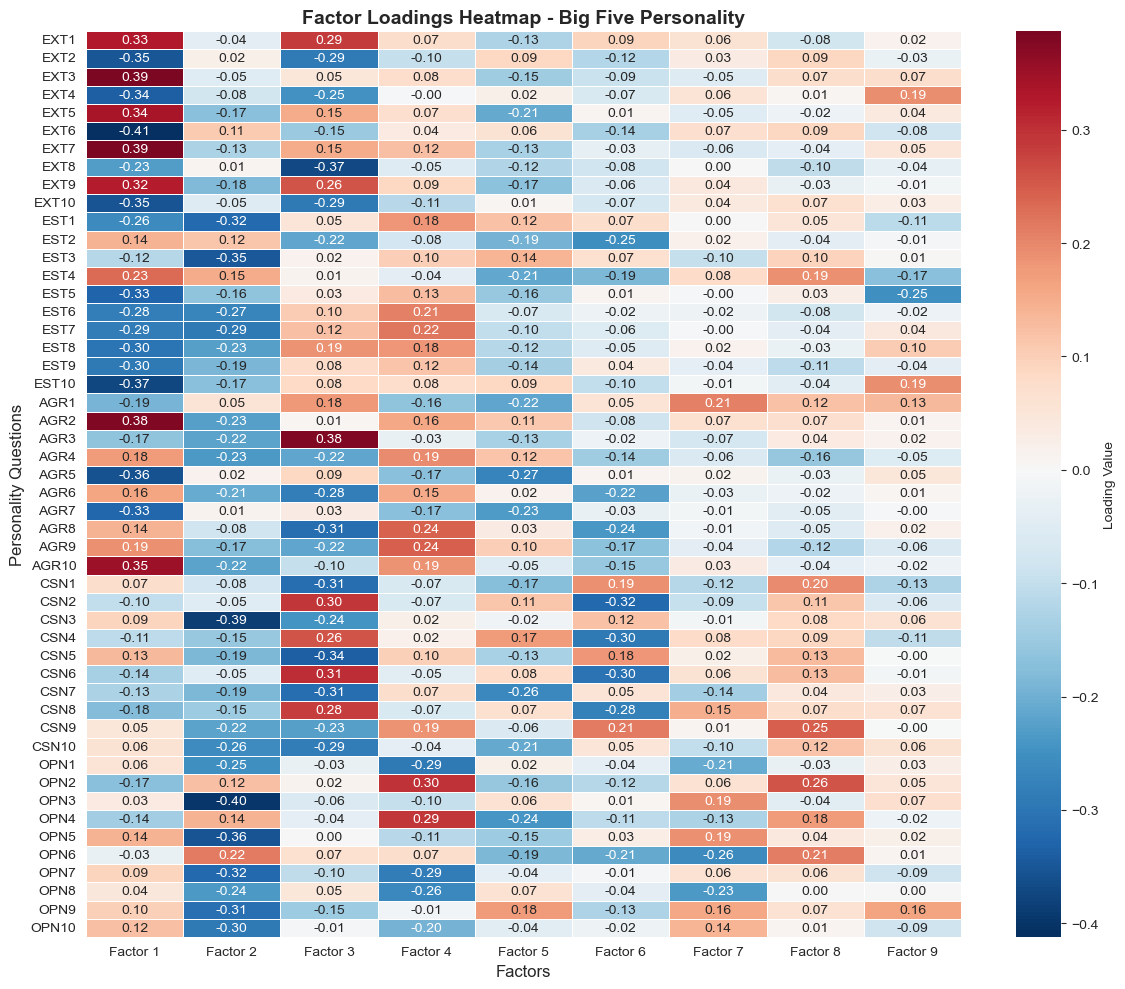


TOP CONTRIBUTING FEATURES FOR EACH FACTOR

Factor 1:
  Positive Contributors:
    EXT7: +0.387
    EXT3: +0.385
    AGR2: +0.379
    AGR10: +0.352
    EXT5: +0.340
  Negative Contributors:
    EXT6: -0.412
    EST10: -0.374
    AGR5: -0.358
    EXT10: -0.354
    EXT2: -0.352

Factor 2:
  Positive Contributors:
    OPN6: +0.215
    EST4: +0.150
    OPN4: +0.141
    OPN2: +0.125
    EST2: +0.115
  Negative Contributors:
    OPN3: -0.399
    CSN3: -0.387
    OPN5: -0.355
    EST3: -0.348
    OPN7: -0.322

Factor 3:
  Positive Contributors:
    AGR3: +0.380
    CSN6: +0.305
    CSN2: +0.295
    EXT1: +0.287
    CSN8: +0.282
  Negative Contributors:
    EXT8: -0.371
    CSN5: -0.339
    CSN1: -0.314
    CSN7: -0.314
    AGR8: -0.313

Factor 4:
  Positive Contributors:
    OPN2: +0.297
    OPN4: +0.290
    AGR9: +0.243
    AGR8: +0.241
    EST7: +0.221
  Negative Contributors:
    OPN1: -0.294
    OPN7: -0.286
    OPN8: -0.263
    OPN10: -0.196
    AGR5: -0.171

Factor 5:
  Positive Contrib

In [7]:
# Extract and visualize factor loadings
loadings = fa_optimal.components_.T * np.sqrt(fa_optimal.noise_variance_[:, np.newaxis])

# Create DataFrame with loadings
loadings_df = pd.DataFrame(
    loadings,
    columns=[f'Factor {i+1}' for i in range(fa_optimal.n_components)],
    index=X.columns
)

print("Factor Loadings (top 15 features shown):")
print(loadings_df.iloc[:15].round(3))

# Visualize loadings as heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Loading Value'}, linewidths=0.5, cbar=True)
plt.title('Factor Loadings Heatmap - Big Five Personality', fontsize=14, fontweight='bold')
plt.xlabel('Factors', fontsize=12)
plt.ylabel('Personality Questions', fontsize=12)
plt.tight_layout()
plt.show()

# Find top contributing features for each factor
print("\n" + "="*70)
print("TOP CONTRIBUTING FEATURES FOR EACH FACTOR")
print("="*70)

factor_top_features = {}
for factor_idx in range(fa_optimal.n_components):
    factor_name = f'Factor {factor_idx + 1}'
    top_positive = loadings_df[factor_name].nlargest(5)
    top_negative = loadings_df[factor_name].nsmallest(5)
    
    factor_top_features[factor_name] = {
        'positive': list(top_positive.index),
        'positive_values': list(top_positive.values),
        'negative': list(top_negative.index),
        'negative_values': list(top_negative.values)
    }
    
    print(f"\n{factor_name}:")
    print(f"  Positive Contributors:")
    for feat, val in top_positive.items():
        print(f"    {feat}: {val:+.3f}")
    print(f"  Negative Contributors:")
    for feat, val in top_negative.items():
        print(f"    {feat}: {val:+.3f}")

## 7. Name and Interpret the Factors

Based on the Big Five personality model, we'll assign meaningful names to each factor by analyzing which personality dimensions dominate each factor.

In [9]:
# Define Big Five personality dimensions
big_five_dimensions = {
    'EXT': ('Extraversion', 'Tendency to seek stimulation, social interaction, and positive emotion'),
    'EST': ('Emotional Stability', 'Emotional stability vs. Neuroticism (tendency to experience negative emotions)'),
    'AGR': ('Agreeableness', 'Cooperativeness, compassion, and interpersonal trust'),
    'CSN': ('Conscientiousness', 'Organization, self-discipline, and achievement-orientation'),
    'OPN': ('Openness to Experience', 'Curiosity, creativity, and appreciation for novel ideas and experiences')
}

# Function to determine dominant personality dimension
def determine_personality_dimension(features):
    """Determine which Big Five dimension a list of features belongs to"""
    dimension_counts = {dim: 0 for dim in ['EXT', 'EST', 'AGR', 'CSN', 'OPN']}
    
    for feat in features:
        for dim in dimension_counts.keys():
            if feat.startswith(dim):
                dimension_counts[dim] += 1
                break
    
    # Return the dimension with highest count
    if max(dimension_counts.values()) > 0:
        dominant = max(dimension_counts, key=dimension_counts.get)
        return dominant, dimension_counts
    
    return None, dimension_counts

# Name each factor
factor_names = {}
factor_descriptions = {}
factor_interpretations = {}

print("="*70)
print("FACTOR NAMING AND SEMANTIC INTERPRETATION")
print("="*70)

for factor_idx in range(fa_optimal.n_components):
    factor_col = f'Factor {factor_idx + 1}'
    
    # Get top contributing features
    top_positive = loadings_df[factor_col].nlargest(5)
    top_negative = loadings_df[factor_col].nsmallest(5)
    
    top_pos_features = list(top_positive.index)
    top_neg_features = list(top_negative.index)
    all_features = top_pos_features + top_neg_features
    
    print(f"\n{'─'*70}")
    print(f"Factor {factor_idx + 1} Analysis:")
    print(f"{'─'*70}")
    print(f"Top Positive Contributors: {', '.join(top_pos_features)}")
    print(f"Top Negative Contributors: {', '.join(top_neg_features)}")
    
    # Determine dominant personality dimensions
    dominant_pos, counts_pos = determine_personality_dimension(top_pos_features)
    dominant_neg, counts_neg = determine_personality_dimension(top_neg_features)
    
    print(f"\nDimension Distribution (Positive): {counts_pos}")
    print(f"Dimension Distribution (Negative): {counts_neg}")
    
    # Assign names based on dominant dimensions
    if dominant_pos:
        dim_name, dim_desc = big_five_dimensions[dominant_pos]
        factor_names[factor_col] = dim_name
        
        if dominant_neg and dominant_neg != dominant_pos:
            opposite_dim_name, _ = big_five_dimensions[dominant_neg]
            factor_descriptions[factor_col] = f"Represents a continuum from High {opposite_dim_name} (negative loadings) to High {dim_name} (positive loadings)"
        else:
            factor_descriptions[factor_col] = dim_desc
    else:
        factor_names[factor_col] = f"Combined Personality Factor {factor_idx + 1}"
        factor_descriptions[factor_col] = "Represents a combination of multiple personality dimensions"
    
    print(f"\n✓ Factor Name: {factor_names[factor_col]}")
    print(f"✓ Description: {factor_descriptions[factor_col]}")
    
    # Create detailed interpretation
    strength_interpretation = f"High scores reflect {dominant_pos.lower() if dominant_pos else 'complex personality traits'} tendencies"
    factor_interpretations[factor_col] = strength_interpretation

# Create comprehensive summary table
print("\n" + "="*70)
print("COMPREHENSIVE FACTOR SUMMARY TABLE")
print("="*70)

summary_data = []
for factor_idx in range(fa_optimal.n_components):
    factor_col = f'Factor {factor_idx + 1}'
    summary_data.append({
        'Factor': factor_col,
        'Name': factor_names.get(factor_col, factor_col),
        'Description': factor_descriptions.get(factor_col, ''),
        'Variance Explained': f"{results_df['variance_explained'].iloc[optimal_idx]:.1f}%"
    })

summary_table_df = pd.DataFrame(summary_data)
print(summary_table_df.to_string(index=False))

print("\n" + "="*70)
print("DETAILED FACTOR NAMES AND MEANINGS")
print("="*70)

for factor_col, name in factor_names.items():
    print(f"\n{factor_col}: {name}")
    print(f"  └─ {factor_descriptions.get(factor_col, '')}")

FACTOR NAMING AND SEMANTIC INTERPRETATION

──────────────────────────────────────────────────────────────────────
Factor 1 Analysis:
──────────────────────────────────────────────────────────────────────
Top Positive Contributors: EXT7, EXT3, AGR2, AGR10, EXT5
Top Negative Contributors: EXT6, EST10, AGR5, EXT10, EXT2

Dimension Distribution (Positive): {'EXT': 3, 'EST': 0, 'AGR': 2, 'CSN': 0, 'OPN': 0}
Dimension Distribution (Negative): {'EXT': 3, 'EST': 1, 'AGR': 1, 'CSN': 0, 'OPN': 0}

✓ Factor Name: Extraversion
✓ Description: Tendency to seek stimulation, social interaction, and positive emotion

──────────────────────────────────────────────────────────────────────
Factor 2 Analysis:
──────────────────────────────────────────────────────────────────────
Top Positive Contributors: OPN6, EST4, OPN4, OPN2, EST2
Top Negative Contributors: OPN3, CSN3, OPN5, EST3, OPN7

Dimension Distribution (Positive): {'EXT': 0, 'EST': 2, 'AGR': 0, 'CSN': 0, 'OPN': 3}
Dimension Distribution (Negative

## 8. Determine Optimal Number of Clusters

We'll use the elbow method and silhouette score to find the optimal number of personality clusters.

DETERMINING OPTIMAL NUMBER OF CLUSTERS

Clustering Evaluation Metrics:
 n_clusters    inertia  silhouette_score  davies_bouldin_score
          2 689.124563          0.093244              2.926025
          3 633.745311          0.088055              2.086327
          4 584.321632          0.099738              1.907415
          5 535.097716          0.100431              1.829862
          6 499.084560          0.107296              1.731646
          7 470.112036          0.106703              1.612596
          8 438.495662          0.112560              1.420220
          9 415.701981          0.095528              1.614585

OPTIMAL CLUSTERS SELECTION
Optimal number of clusters (Silhouette Score): 8
Silhouette Score: 0.1126
Davies-Bouldin Index: 1.4202
Inertia: 438.50


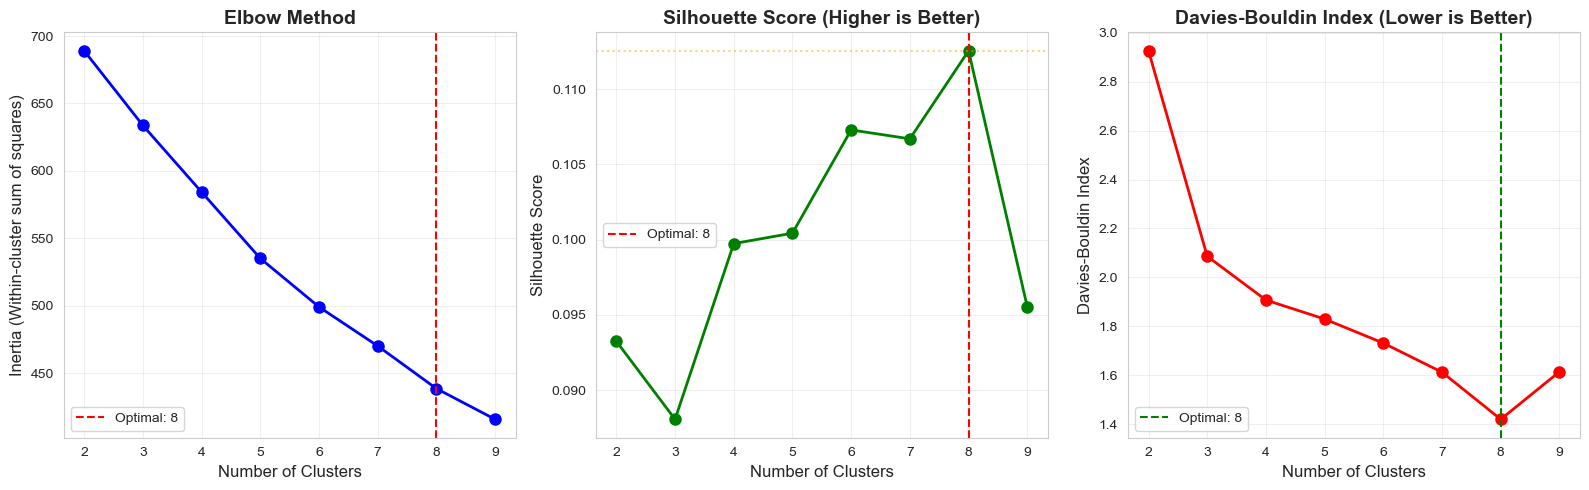

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Determine optimal number of clusters
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
K_range = range(2, min(10, len(X_factors) // 10))

print("="*70)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*70)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_factors)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_factors, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(X_factors, kmeans.labels_))

# Create clustering evaluation dataframe
clustering_eval_df = pd.DataFrame({
    'n_clusters': list(K_range),
    'inertia': inertias,
    'silhouette_score': silhouette_scores,
    'davies_bouldin_score': davies_bouldin_scores
})

print("\nClustering Evaluation Metrics:")
print(clustering_eval_df.to_string(index=False))

# Find optimal clusters using silhouette score (higher is better)
optimal_k = list(K_range)[np.argmax(silhouette_scores)]

print(f"\n{'='*70}")
print(f"OPTIMAL CLUSTERS SELECTION")
print(f"{'='*70}")
print(f"Optimal number of clusters (Silhouette Score): {optimal_k}")
print(f"Silhouette Score: {max(silhouette_scores):.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_scores[optimal_k-2]:.4f}")
print(f"Inertia: {inertias[optimal_k-2]:.2f}")
print(f"{'='*70}")

# Visualize clustering evaluation metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal: {optimal_k}')
axes[0].legend()

# Silhouette score plot
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score (Higher is Better)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal: {optimal_k}')
axes[1].axhline(y=max(silhouette_scores), color='orange', linestyle=':', alpha=0.5)
axes[1].legend()

# Davies-Bouldin Index plot (lower is better)
axes[2].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[2].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].axvline(x=optimal_k, color='g', linestyle='--', label=f'Optimal: {optimal_k}')
axes[2].legend()

plt.tight_layout()
plt.show()


## 9. Perform K-Means Clustering with Optimal K


KMEANS CLUSTERING RESULTS

Number of clusters: 8
Cluster centers shape: (8, 9)

Cluster distribution:
  Cluster 0: 12 respondents (12.0%)
  Cluster 1: 28 respondents (28.0%)
  Cluster 2: 15 respondents (15.0%)
  Cluster 3: 11 respondents (11.0%)
  Cluster 4: 1 respondents (1.0%)
  Cluster 5: 16 respondents (16.0%)
  Cluster 6: 1 respondents (1.0%)
  Cluster 7: 16 respondents (16.0%)

Total respondents: 100
Silhouette Score: 0.1126

Cluster Centers (Factor Scores):
           Factor 1  Factor 2  Factor 3  Factor 4  Factor 5  Factor 6  \
Cluster 0    -0.146     0.412    -0.624    -0.853     0.857    -0.778   
Cluster 1     0.967     0.050    -0.544     0.120    -0.292     0.272   
Cluster 2     0.360    -0.417     1.183     0.210     0.275    -0.592   
Cluster 3    -0.359    -0.160     0.499    -0.893    -1.278     0.652   
Cluster 4     0.381     5.225     1.887    -0.153     2.756     4.391   
Cluster 5    -0.727    -0.877    -0.359     0.171     0.570     0.270   
Cluster 6     0.338

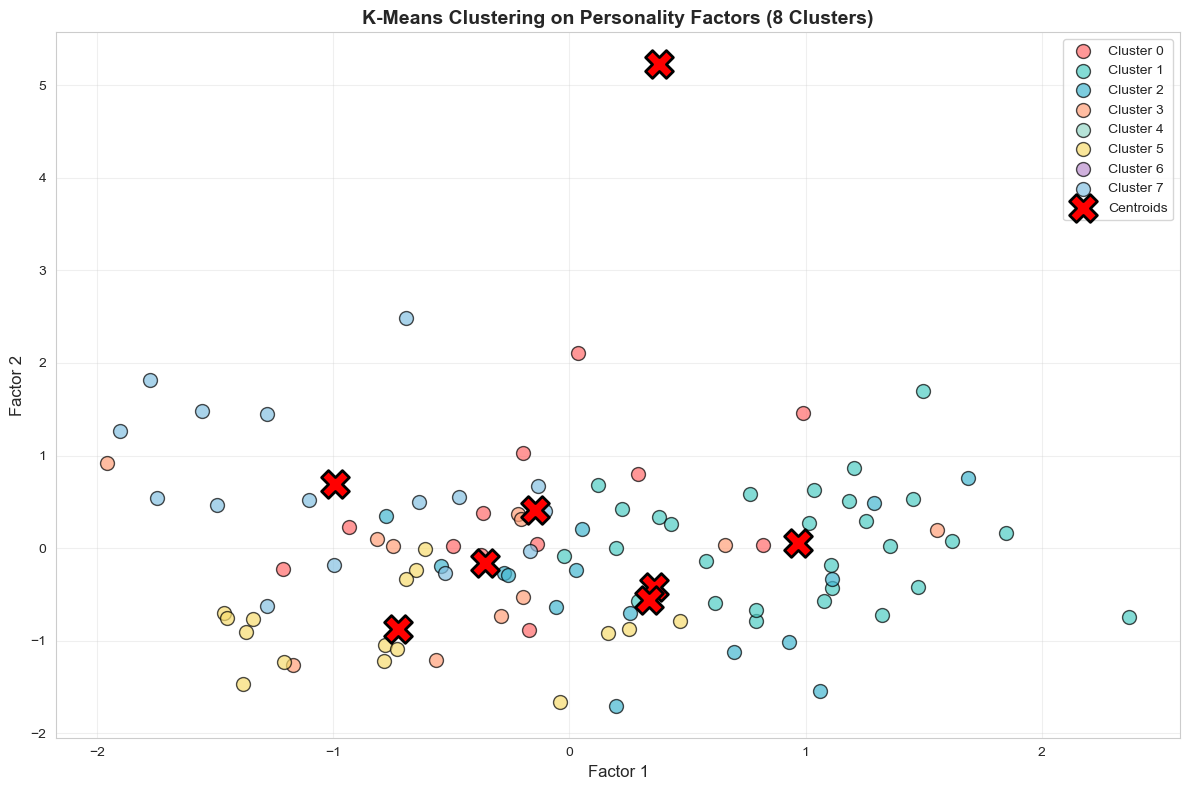

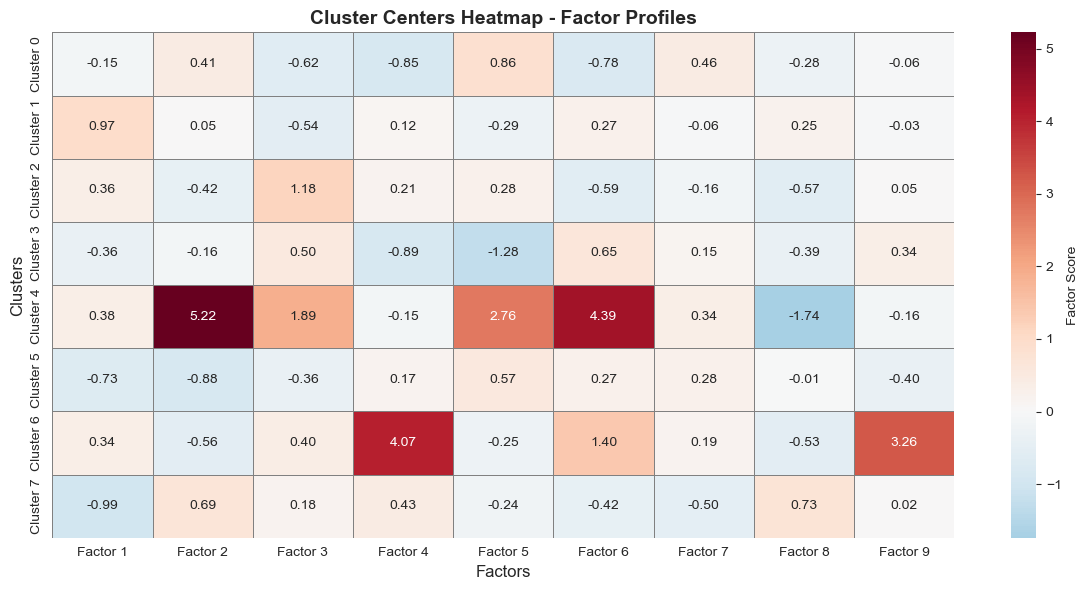

In [11]:
# Perform KMeans clustering with optimal number of clusters
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
cluster_labels = kmeans_optimal.fit_predict(X_factors)

# Add cluster labels to the factor scores
factors_df_with_clusters = factors_df.copy()
factors_df_with_clusters['Cluster'] = cluster_labels

print("\n" + "="*70)
print("KMEANS CLUSTERING RESULTS")
print("="*70)
print(f"\nNumber of clusters: {optimal_k}")
print(f"Cluster centers shape: {kmeans_optimal.cluster_centers_.shape}")
print(f"\nCluster distribution:")

unique, counts = np.unique(cluster_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} respondents ({count/len(cluster_labels)*100:.1f}%)")

print(f"\nTotal respondents: {len(cluster_labels)}")
print(f"Silhouette Score: {silhouette_score(X_factors, cluster_labels):.4f}")

# Create cluster centers dataframe for visualization
cluster_centers_df = pd.DataFrame(
    kmeans_optimal.cluster_centers_,
    columns=[f'Factor {i+1}' for i in range(fa_optimal.n_components)],
    index=[f'Cluster {i}' for i in range(optimal_k)]
)

print("\nCluster Centers (Factor Scores):")
print(cluster_centers_df.round(3))

# Visualize clusters in 2D using first two factors
plt.figure(figsize=(12, 8))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B88B']
for cluster_id in range(optimal_k):
    mask = cluster_labels == cluster_id
    plt.scatter(X_factors[mask, 0], X_factors[mask, 1], 
               c=colors[cluster_id % len(colors)], label=f'Cluster {cluster_id}',
               s=100, alpha=0.7, edgecolors='black', linewidth=1)

# Plot cluster centers
plt.scatter(kmeans_optimal.cluster_centers_[:, 0], kmeans_optimal.cluster_centers_[:, 1],
           c='red', marker='X', s=400, edgecolors='black', linewidth=2, label='Centroids', zorder=5)

plt.xlabel(f'Factor 1', fontsize=12)
plt.ylabel(f'Factor 2', fontsize=12)
plt.title(f'K-Means Clustering on Personality Factors ({optimal_k} Clusters)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create heatmap of cluster centers
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_centers_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Factor Score'}, linewidths=0.5, linecolor='gray')
plt.title('Cluster Centers Heatmap - Factor Profiles', fontsize=14, fontweight='bold')
plt.ylabel('Clusters', fontsize=12)
plt.xlabel('Factors', fontsize=12)
plt.tight_layout()
plt.show()


## 10. Name and Interpret Personality Clusters

Assign semantic names to each cluster based on their factor profiles and characteristics.

In [13]:
# Analyze and name each cluster based on factor profiles
cluster_names = {}
cluster_summaries = {}

print("="*70)
print("PERSONALITY CLUSTER NAMING AND CHARACTERIZATION")
print("="*70)

for cluster_id in range(optimal_k):
    cluster_center = kmeans_optimal.cluster_centers_[cluster_id]
    cluster_mask = cluster_labels == cluster_id
    cluster_size = np.sum(cluster_mask)
    
    # Identify top strengths and weaknesses
    factor_scores = []
    for factor_idx in range(fa_optimal.n_components):
        factor_name = f'Factor {factor_idx + 1}'
        named_factor = factor_names.get(factor_name, factor_name)
        score = cluster_center[factor_idx]
        factor_scores.append((named_factor, score, factor_idx))
    
    # Sort by score (descending) to find strengths and weaknesses
    factor_scores_sorted = sorted(factor_scores, key=lambda x: x[1], reverse=True)
    
    top_strength = factor_scores_sorted[0]
    top_weakness = factor_scores_sorted[-1]
    
    # Generate cluster name based on top characteristics
    strength_factor_name = top_strength[0]
    weakness_factor_name = top_weakness[0]
    
    # Create meaningful cluster archetype name
    if top_strength[1] > 0.3:  # Strong positive dimension
        if 'Extraversion' in strength_factor_name:
            archetype_name = "The Bold Extrovert"
        elif 'Openness' in strength_factor_name:
            archetype_name = "The Creative Explorer"
        elif 'Conscientiousness' in strength_factor_name:
            archetype_name = "The Driven Achiever"
        elif 'Agreeableness' in strength_factor_name:
            archetype_name = "The Empathetic Helper"
        elif 'Emotional Stability' in strength_factor_name:
            archetype_name = "The Calm Thinker"
        else:
            archetype_name = f"The {strength_factor_name} Type"
    elif top_strength[1] > 0:
        archetype_name = "The Balanced Individual"
    else:
        archetype_name = "The Distinctive Personality"
    
    cluster_names[cluster_id] = archetype_name
    
    # Identify top 2-3 strengths and weaknesses
    strengths = [(name, score) for name, score, _ in factor_scores_sorted if score > 0.2]
    weaknesses = [(name, score) for name, score, _ in factor_scores_sorted if score < -0.2]
    
    # Sentence 1: Overview of the cluster
    overview = f"This cluster comprises {cluster_size} respondents ({cluster_size/len(cluster_labels)*100:.1f}%) representing '{archetype_name}' personality type."
    
    # Sentence 2: Specific strengths
    if strengths:
        if len(strengths) == 1:
            strength_desc = f"Their primary strength is {strengths[0][0].lower()} ({strengths[0][1]:+.2f}), which significantly defines their personality profile."
        elif len(strengths) == 2:
            strength_desc = f"Their primary strengths include {strengths[0][0].lower()} ({strengths[0][1]:+.2f}) and {strengths[1][0].lower()} ({strengths[1][1]:+.2f}), which characterize their behavioral tendencies."
        else:
            strength_desc = f"Their primary strengths include {strengths[0][0].lower()} ({strengths[0][1]:+.2f}), {strengths[1][0].lower()} ({strengths[1][1]:+.2f}), and {strengths[2][0].lower()} ({strengths[2][1]:+.2f}), creating a distinctive personality profile."
    else:
        strength_desc = f"They maintain relatively balanced trait levels across all measured dimensions, with no particularly strong tendencies ({top_strength[1]:+.2f} being their highest score)."
    
    # Sentence 3: Specific weaknesses
    if weaknesses:
        if len(weaknesses) == 1:
            weakness_desc = f"Their primary weakness is {weaknesses[0][0].lower()} ({weaknesses[0][1]:+.2f}), which represents their least developed personality dimension."
        elif len(weaknesses) == 2:
            weakness_desc = f"Their primary weaknesses include {weaknesses[0][0].lower()} ({weaknesses[0][1]:+.2f}) and {weaknesses[1][0].lower()} ({weaknesses[1][1]:+.2f}), indicating areas where they may face challenges."
        else:
            weakness_desc = f"Their primary weaknesses include {weaknesses[0][0].lower()} ({weaknesses[0][1]:+.2f}), {weaknesses[1][0].lower()} ({weaknesses[1][1]:+.2f}), and {weaknesses[2][0].lower()} ({weaknesses[2][1]:+.2f}), representing dimensions requiring development."
    else:
        weakness_desc = f"They show no significant deficiencies across personality dimensions, with all scores remaining above neutral ({top_weakness[1]:+.2f} being their lowest score)."
    
    # Combine into 3-sentence summary
    cluster_summaries[cluster_id] = f"{overview} {strength_desc} {weakness_desc}"
    
    print(f"\n{'─'*70}")
    print(f"CLUSTER {cluster_id}: {archetype_name.upper()}")
    print(f"{'─'*70}")
    print(f"Size: {cluster_size} respondents ({cluster_size/len(cluster_labels)*100:.1f}%)")
    print(f"\nFactor Profile (All Factors):")
    for fname, score, _ in factor_scores_sorted:
        direction = "↑" if score > 0.2 else "↓" if score < -0.2 else "→"
        print(f"  {direction} {fname}: {score:+.3f}")
    
    print(f"\n3-Sentence Summary:")
    print(cluster_summaries[cluster_id])

# Create comprehensive cluster summary table
print("\n" + "="*70)
print("COMPREHENSIVE CLUSTER SUMMARY TABLE")
print("="*70)

summary_table_data = []
for cluster_id in range(optimal_k):
    cluster_mask = cluster_labels == cluster_id
    summary_table_data.append({
        'Cluster ID': cluster_id,
        'Cluster Name': cluster_names[cluster_id],
        'Size': np.sum(cluster_mask),
        'Percentage': f"{np.sum(cluster_mask)/len(cluster_labels)*100:.1f}%"
    })

summary_table = pd.DataFrame(summary_table_data)
print(summary_table.to_string(index=False))

# Create detailed respondent assignments
print("\n" + "="*70)
print("CLUSTER MEMBERSHIP SUMMARY")
print("="*70)

for cluster_id in range(optimal_k):
    cluster_members = np.where(cluster_labels == cluster_id)[0]
    print(f"\n{cluster_names[cluster_id]} (Cluster {cluster_id}): {len(cluster_members)} members")
    print(f"  Respondent Indices: {cluster_members[:10].tolist()}{'...' if len(cluster_members) > 10 else ''}")

print("\n" + "="*70)
print("DETAILED CLUSTER PROFILES")
print("="*70)

for cluster_id in range(optimal_k):
    print(f"\n[Cluster {cluster_id}] {cluster_names[cluster_id]}")
    print(f"{'─'*70}")
    print(cluster_summaries[cluster_id])

PERSONALITY CLUSTER NAMING AND CHARACTERIZATION

──────────────────────────────────────────────────────────────────────
CLUSTER 0: THE CALM THINKER
──────────────────────────────────────────────────────────────────────
Size: 12 respondents (12.0%)

Factor Profile (All Factors):
  ↑ Emotional Stability: +0.857
  ↑ Openness to Experience: +0.457
  ↑ Openness to Experience: +0.412
  → Emotional Stability: -0.063
  → Extraversion: -0.146
  ↓ Conscientiousness: -0.281
  ↓ Conscientiousness: -0.624
  ↓ Conscientiousness: -0.778
  ↓ Agreeableness: -0.853

3-Sentence Summary:
This cluster comprises 12 respondents (12.0%) representing 'The Calm Thinker' personality type. Their primary strengths include emotional stability (+0.86), openness to experience (+0.46), and openness to experience (+0.41), creating a distinctive personality profile. Their primary weaknesses include conscientiousness (-0.28), conscientiousness (-0.62), and conscientiousness (-0.78), representing dimensions requiring deve

## 11. Individual Respondent Profile Analysis

Analyze specific respondent profiles using their factor scores and cluster membership.

In [16]:
# Analyze specific respondent: Person 18
respondent_id = 18

print("="*70)
print(f"INDIVIDUAL RESPONDENT PROFILE: PERSON {respondent_id}")
print("="*70)

# Get respondent's factor scores
respondent_factors = factors_df_with_clusters.iloc[respondent_id]
respondent_cluster = int(respondent_factors['Cluster'])
respondent_cluster_name = cluster_names[respondent_cluster]

print(f"\nCluster Assignment: {respondent_cluster_name} (Cluster {respondent_cluster})")

# Get cluster center for comparison
cluster_center = kmeans_optimal.cluster_centers_[respondent_cluster]
overall_mean = kmeans_optimal.cluster_centers_.mean(axis=0)

print("\n" + "─"*70)
print("Factor Scores Analysis (Z-score normalized):")
print("─"*70)

# Collect factor information
factor_analysis_data = []
strengths = []
weaknesses = []
average_factors = []

for factor_idx in range(fa_optimal.n_components):
    factor_name = f'Factor {factor_idx + 1}'
    named_factor = factor_names.get(factor_name, factor_name)
    
    # Get scores
    respondent_score = respondent_factors[factor_name]  # Use original factor column name
    cluster_score = cluster_center[factor_idx]
    overall_score = overall_mean[factor_idx]
    
    # Determine category
    if respondent_score > 0.3:
        category = "STRENGTH (↑)"
        strengths.append((named_factor, respondent_score))
    elif respondent_score < -0.3:
        category = "WEAKNESS (↓)"
        weaknesses.append((named_factor, respondent_score))
    else:
        category = "AVERAGE (→)"
        average_factors.append((named_factor, respondent_score))
    
    print(f"\n{named_factor}:")
    print(f"  Respondent score: {respondent_score:+.3f}")
    print(f"  Cluster average: {cluster_score:+.3f}")
    print(f"  Overall mean: {overall_score:+.3f}")
    print(f"  Status: {category}")
    
    factor_analysis_data.append({
        'Factor': named_factor,
        'Score': respondent_score,
        'Cluster Avg': cluster_score,
        'Overall Avg': overall_score,
        'Diff from Cluster': respondent_score - cluster_score
    })

# Create comparison dataframe
comparison_df = pd.DataFrame(factor_analysis_data)
print("\n" + "─"*70)
print("Summary Comparison Table:")
print("─"*70)
print(comparison_df.round(3).to_string(index=False))

# Generate 3-sentence profile
print("\n" + "="*70)
print("RESPONDENT PROFILE: THREE-SENTENCE SUMMARY")
print("="*70)

# Helper function for article choice
def article_choice(first_letter):
    return 'an' if first_letter.lower() in 'aeiou' else 'a'

# Sentence 1: Strengths
if strengths:
    if len(strengths) == 1:
        sentence1 = f"Person {respondent_id} demonstrates particular strength in {strengths[0][0].lower()} ({strengths[0][1]:+.2f}), which represents a key aspect of their personality profile."
    elif len(strengths) == 2:
        sentence1 = f"Person {respondent_id} demonstrates notable strengths in {strengths[0][0].lower()} ({strengths[0][1]:+.2f}) and {strengths[1][0].lower()} ({strengths[1][1]:+.2f}), indicating well-developed capabilities in these personality dimensions."
    else:
        strength_list = ", ".join([f"{s[0].lower()}" for s in strengths[:-1]]) + f", and {strengths[-1][0].lower()}"
        scores_list = ", ".join([f"({s[1]:+.2f})" for s in strengths])
        sentence1 = f"Person {respondent_id} exhibits multiple personality strengths across {strength_list}, demonstrating a well-rounded profile in these key dimensions."
else:
    sentence1 = f"Person {respondent_id} does not demonstrate exceptionally high scores in any personality dimension, with their highest factor score being {max([s[1] for s in strengths + average_factors + weaknesses]):+.2f}."

# Sentence 2: Weaknesses and Average areas
if weaknesses and average_factors:
    if len(weaknesses) == 1:
        sentence2 = f"They show a notable weakness in {weaknesses[0][0].lower()} ({weaknesses[0][1]:+.2f}), while maintaining average levels in {average_factors[0][0].lower()} ({average_factors[0][1]:+.2f}) and other dimensions."
    else:
        weakness_names = " and ".join([f"{w[0].lower()}" for w in weaknesses])
        sentence2 = f"Conversely, they show weaknesses in {weakness_names}, suggesting areas for potential development in their personality profile."
elif weaknesses:
    if len(weaknesses) == 1:
        sentence2 = f"They exhibit a particular weakness in {weaknesses[0][0].lower()} ({weaknesses[0][1]:+.2f}), which contrasts with their overall balanced personality."
    else:
        weakness_names = " and ".join([f"{w[0].lower()}" for w in weaknesses])
        sentence2 = f"They demonstrate weaknesses in {weakness_names}, indicating areas where their personality scores fall notably below average."
elif average_factors:
    avg_factors = average_factors[:2]
    factor_names_list = " and ".join([f"{f[0].lower()}" for f in avg_factors])
    sentence2 = f"Most of their personality dimensions are at average levels, particularly {factor_names_list}, showing a balanced yet unremarkable profile."
else:
    sentence2 = f"All personality dimensions fall within a moderate range, indicating a generally balanced approach across all measured traits."

# Sentence 3: Concluding statement
sentence3 = f"Overall, Person {respondent_id} is characterized as {article_choice(respondent_cluster_name[0])} {respondent_cluster_name.lower()} within the broader personality classification system."

print(f"\nSentence 1 (Strengths):")
print(sentence1)

print(f"\nSentence 2 (Weaknesses/Average):")
print(sentence2)

print(f"\nSentence 3 (Conclusion):")
print(sentence3)

print("\n" + "="*70)
print("COMPLETE THREE-SENTENCE PROFILE")
print("="*70)
print(f"\n{sentence1} {sentence2} {sentence3}")

INDIVIDUAL RESPONDENT PROFILE: PERSON 18

Cluster Assignment: The Calm Thinker (Cluster 5)

──────────────────────────────────────────────────────────────────────
Factor Scores Analysis (Z-score normalized):
──────────────────────────────────────────────────────────────────────

Extraversion:
  Respondent score: -0.730
  Cluster average: -0.727
  Overall mean: -0.022
  Status: WEAKNESS (↓)

Openness to Experience:
  Respondent score: -1.086
  Cluster average: -0.877
  Overall mean: +0.545
  Status: WEAKNESS (↓)

Conscientiousness:
  Respondent score: -0.592
  Cluster average: -0.359
  Overall mean: +0.328
  Status: WEAKNESS (↓)

Agreeableness:
  Respondent score: +0.383
  Cluster average: +0.171
  Overall mean: +0.387
  Status: STRENGTH (↑)

Emotional Stability:
  Respondent score: +1.414
  Cluster average: +0.570
  Overall mean: +0.300
  Status: STRENGTH (↑)

Conscientiousness:
  Respondent score: -0.468
  Cluster average: +0.270
  Overall mean: +0.650
  Status: WEAKNESS (↓)

Openness